# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the clounterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [3]:
import  matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(8,8)

Please insert you  firstname  and name below

In [4]:
from  sklearn.model_selection import train_test_split
seed = 31287

In [5]:
data = pd.read_csv('data/banknotes_data.csv')

In [6]:
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [7]:
data.describe()

,a0,a1,a2,a3,counterfeit
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,0.431116,1.902054,1.426607,-1.220393,0.444254
std,2.845672,5.942260,4.397341,2.101777,0.497096
min,-7.042100,-13.773100,-5.286100,-7.871900,0.000000
25%,-1.770900,-1.916200,-1.664300,-2.466150,0.000000
50%,0.471345,2.408650,0.567365,-0.614450,0.000000
75%,2.816925,6.800675,3.338825,0.394810,1.000000
max,6.824800,12.730200,17.927400,2.449500,1.000000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


In [9]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)

In [10]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0


In [11]:
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

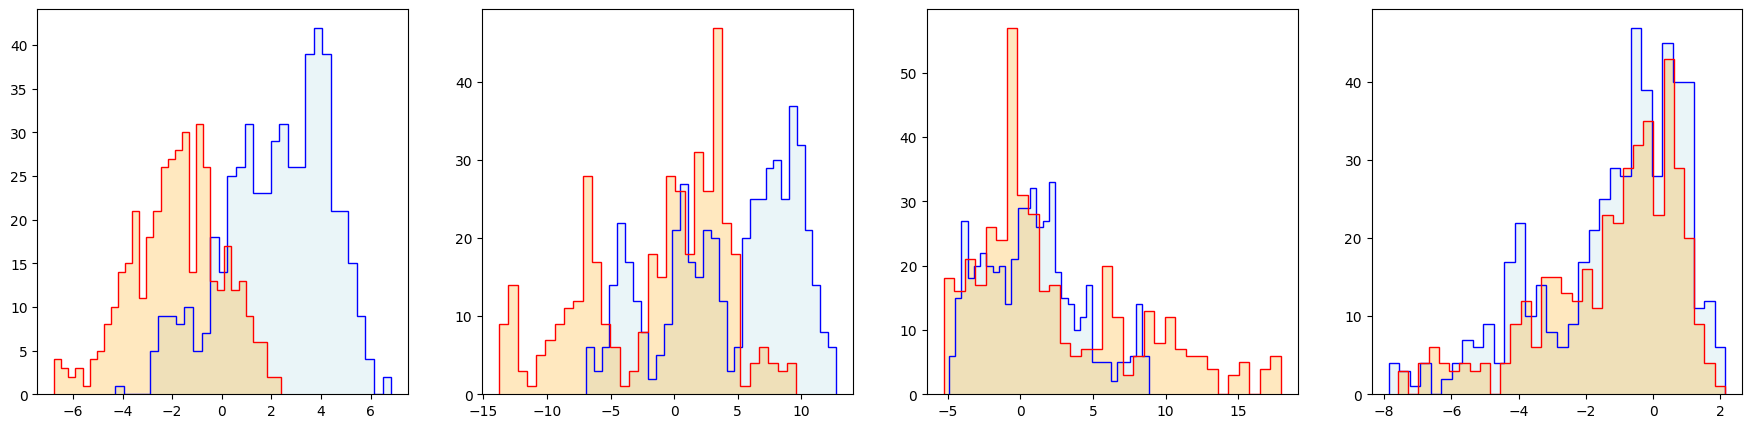

In [12]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

## Problem 2

Using the GaussianNB function construct the Gaussian Bayes classifier using two features. Calculate the confusion matrix (normalized as to show rates), ROC AUC score and plot ROC curve. Do this both for training and validation set. Plot both curves on the same plot. Additionally, on the test set, compare ROC curve obtained with this 2-features classifier and  1-features classifier (the one from Problem 1, previous classes). What is the improvement of AUC score on the test set when we use 2-features classifier instead of 1-features classifier?

Features: ['a0', 'a1']
Train confusion matrix, normalized by true class:
[[0.8957529  0.1042471 ]
 [0.16666667 0.83333333]]
Validation confusion matrix, normalized by true class:
[[0.90769231 0.09230769]
 [0.16346154 0.83653846]]
Train ROC AUC: 0.9500
Validation ROC AUC, a0: 0.9443
Validation ROC AUC, a0+a1: 0.9638
AUC improvement: 0.0195


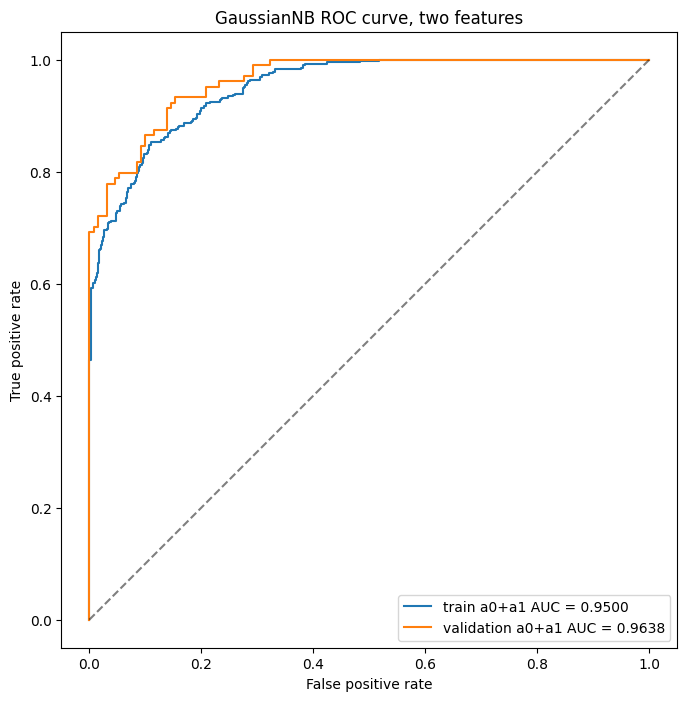

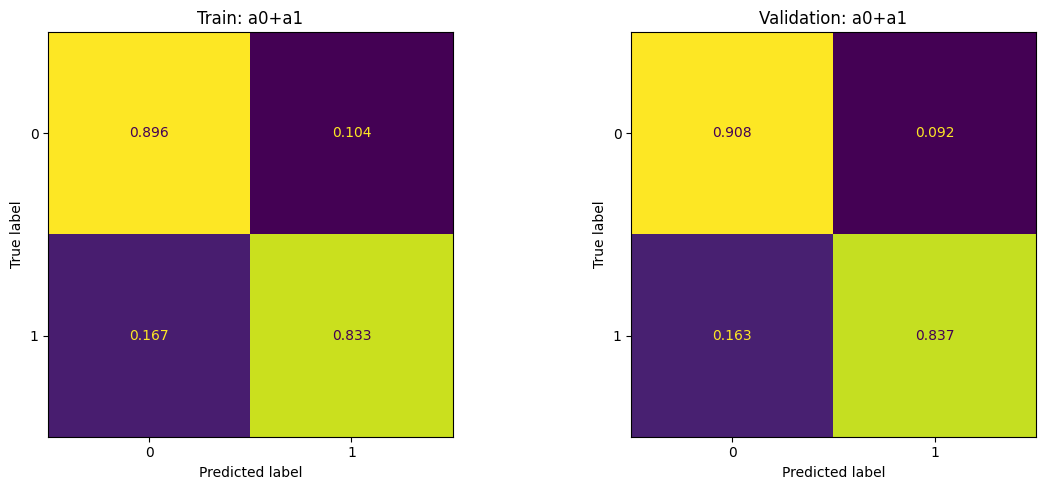

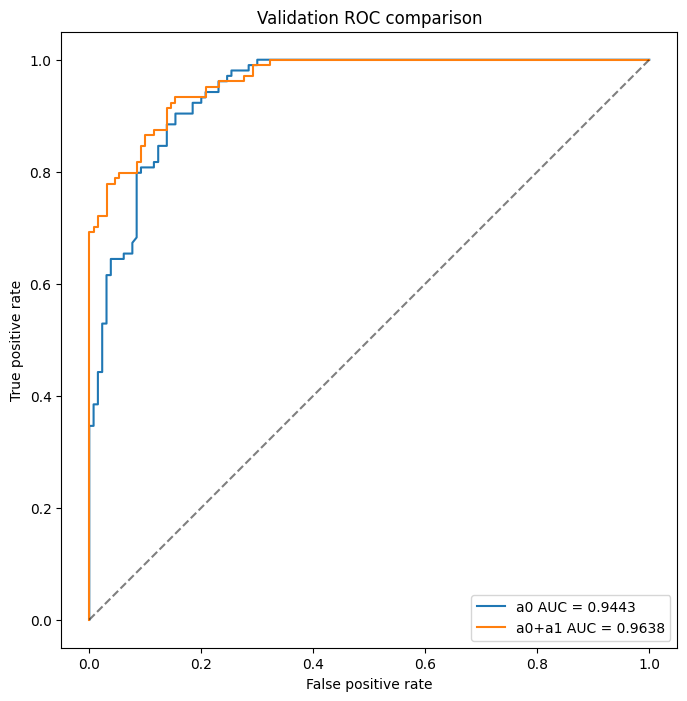

In [13]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

features_a0 = ['a0']
features_a0a1 = ['a0', 'a1']

nb_a0 = GaussianNB()
nb_a0.fit(data_train[features_a0], lbls_train)

nb_a0a1 = GaussianNB()
nb_a0a1.fit(data_train[features_a0a1], lbls_train)

proba_train_a0a1 = nb_a0a1.predict_proba(data_train[features_a0a1])[:, 1]
proba_test_a0a1 = nb_a0a1.predict_proba(data_test[features_a0a1])[:, 1]
pred_train_a0a1 = nb_a0a1.predict(data_train[features_a0a1])
pred_test_a0a1 = nb_a0a1.predict(data_test[features_a0a1])

proba_test_a0 = nb_a0.predict_proba(data_test[features_a0])[:, 1]
fprs_test_a0, tprs_test_a0, _ = roc_curve(lbls_test, proba_test_a0)
fprs_train_a0a1, tprs_train_a0a1, _ = roc_curve(lbls_train, proba_train_a0a1)
fprs_test_a0a1, tprs_test_a0a1, _ = roc_curve(lbls_test, proba_test_a0a1)

auc_test_a0 = roc_auc_score(lbls_test, proba_test_a0)
auc_train_a0a1 = roc_auc_score(lbls_train, proba_train_a0a1)
auc_test_a0a1 = roc_auc_score(lbls_test, proba_test_a0a1)

print('Features:', features_a0a1)
print('Train confusion matrix, normalized by true class:')
print(confusion_matrix(lbls_train, pred_train_a0a1, normalize='true'))
print('Validation confusion matrix, normalized by true class:')
print(confusion_matrix(lbls_test, pred_test_a0a1, normalize='true'))
print(f'Train ROC AUC: {auc_train_a0a1:.4f}')
print(f'Validation ROC AUC, a0: {auc_test_a0:.4f}')
print(f'Validation ROC AUC, a0+a1: {auc_test_a0a1:.4f}')
print(f'AUC improvement: {auc_test_a0a1 - auc_test_a0:.4f}')

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(fprs_train_a0a1, tprs_train_a0a1, label=f'train a0+a1 AUC = {auc_train_a0a1:.4f}')
ax.plot(fprs_test_a0a1, tprs_test_a0a1, label=f'validation a0+a1 AUC = {auc_test_a0a1:.4f}')
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('GaussianNB ROC curve, two features')
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    lbls_train, pred_train_a0a1, normalize='true', values_format='.3f', ax=axes[0], colorbar=False
)
axes[0].set_title('Train: a0+a1')
ConfusionMatrixDisplay.from_predictions(
    lbls_test, pred_test_a0a1, normalize='true', values_format='.3f', ax=axes[1], colorbar=False
)
axes[1].set_title('Validation: a0+a1')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(fprs_test_a0, tprs_test_a0, label=f'a0 AUC = {auc_test_a0:.4f}')
ax.plot(fprs_test_a0a1, tprs_test_a0a1, label=f'a0+a1 AUC = {auc_test_a0a1:.4f}')
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('Validation ROC comparison')
ax.legend()
plt.show()


## Problem 3

Same as Problem 2 but now implement Gaussian Naive Bayes using all features. Show confusion matrix only for test set. Compare all three ROC curves on the test set, same with AUC score.

Features: ['a0', 'a1', 'a2', 'a3']
Test confusion matrix, normalized by true class:
[[0.89230769 0.10769231]
 [0.20192308 0.79807692]]
Test ROC AUC, a0: 0.9443
Test ROC AUC, a0+a1: 0.9638
Test ROC AUC, all features: 0.9521


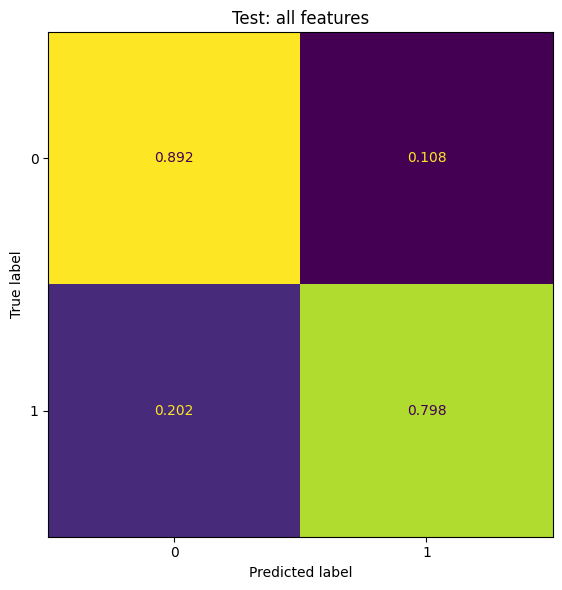

In [14]:
features_all = list(data.columns[:-1])

nb_all = GaussianNB()
nb_all.fit(data_train[features_all], lbls_train)

proba_test_all = nb_all.predict_proba(data_test[features_all])[:, 1]
pred_test_all = nb_all.predict(data_test[features_all])
fprs_test_all, tprs_test_all, _ = roc_curve(lbls_test, proba_test_all)
auc_test_all = roc_auc_score(lbls_test, proba_test_all)

print('Features:', features_all)
print('Test confusion matrix, normalized by true class:')
print(confusion_matrix(lbls_test, pred_test_all, normalize='true'))
print(f'Test ROC AUC, a0: {auc_test_a0:.4f}')
print(f'Test ROC AUC, a0+a1: {auc_test_a0a1:.4f}')
print(f'Test ROC AUC, all features: {auc_test_all:.4f}')

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    lbls_test, pred_test_all, normalize='true', values_format='.3f', ax=ax, colorbar=False
)
ax.set_title('Test: all features')
plt.tight_layout()
plt.show()


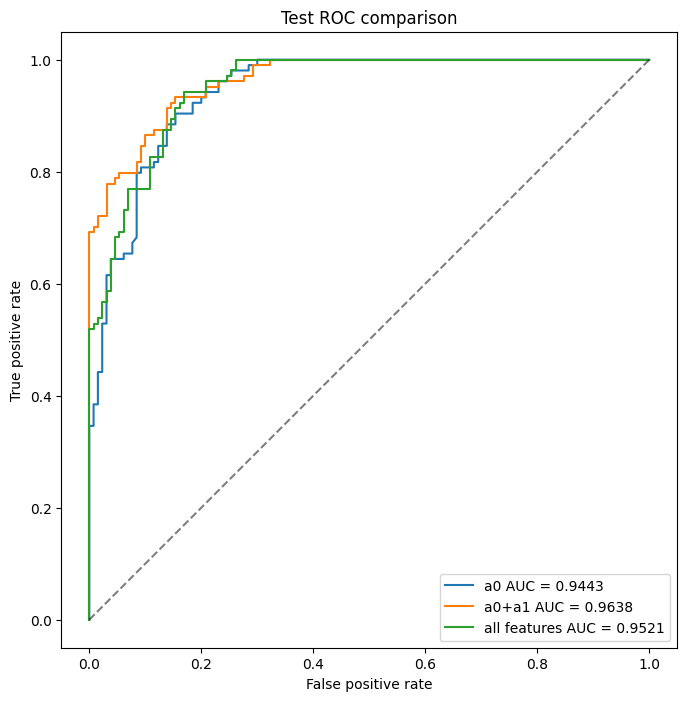

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(fprs_test_a0, tprs_test_a0, label=f'a0 AUC = {auc_test_a0:.4f}')
ax.plot(fprs_test_a0a1, tprs_test_a0a1, label=f'a0+a1 AUC = {auc_test_a0a1:.4f}')
ax.plot(fprs_test_all, tprs_test_all, label=f'all features AUC = {auc_test_all:.4f}')
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('Test ROC comparison')
ax.legend()
plt.show()
